In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [8]:
np.random.seed(42)

data=pd.DataFrame({
    "hours_studied": np.random.randint(1,10,50),
    "attendance": np.random.randint(50,100,50)
})

data.head()

,hours_studied,attendance
0,7,53
1,4,51
2,8,55
3,5,91
4,7,53


In [10]:
x=data[["hours_studied", "attendance"]]

model=KMeans(n_clusters=3, random_state=42, n_init=10)
data["cluster"]= model.fit_predict(x)

data.head()

,hours_studied,attendance,cluster
0,7,53,1
1,4,51,1
2,8,55,1
3,5,91,0
4,7,53,1


In [11]:
score=silhouette_score(x, data["cluster"])
print("Silhouette Score:", score)

Silhouette Score: 0.5276411515754762


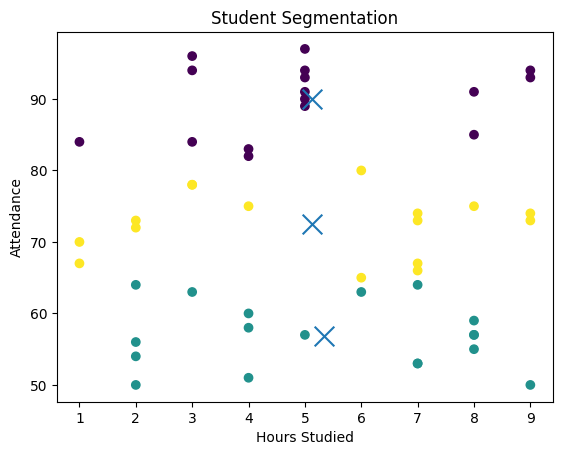

In [13]:
plt.scatter(data["hours_studied"], data["attendance"], c=data["cluster"])

centers=model.cluster_centers_
plt.scatter(centers[:,0], centers[:,1], marker='x', s=200)

plt.xlabel("Hours Studied")
plt.ylabel("Attendance")
plt.title("Student Segmentation")
plt.show()

In [16]:
new_student=[[6,80]]

predicted_cluster=model.predict(new_student)
print("printed cluster:", predicted_cluster[0])

printed cluster: 2


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [17]:
data.groupby("cluster").mean()

,hours_studied,attendance
cluster,,
0,5.125000,90.000000
1,5.333333,56.888889
2,5.125000,72.500000
